In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import copy
from datetime import datetime, timedelta
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import brier_score_loss
from sklearn.metrics import make_scorer
from sklearn.metrics import log_loss
from sklearn.utils.class_weight import compute_class_weight
import sys
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import glob 


from sklearn import datasets, ensemble
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils import class_weight
import json

import xgboost as xgb
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition
import shap

/glade/work/jhayron/conda-envs/pytorch_wr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
gpu_id = 0
ivar_start = 0
ivar_end = 23

path_wrs = '/glade/work/jhayron/Data4Predictability/WR_Series_v20241226.csv'
path_weekly_anoms = '/glade/derecho/scratch/jhayron/Data4Predictability/WeeklyAnoms_DetrendedStd_v3_2dg/'

path_results = '/glade/derecho/scratch/jhayron/Data4Predictability/ResultsXGBoost/Results_v20250326/'
path_results_probs = '/glade/derecho/scratch/jhayron/Data4Predictability/ResultsXGBoost/ResultsProbs_v20250326/'
path_shap= '/glade/derecho/scratch/jhayron/Data4Predictability/ResultsXGBoost/SHAP_Results_v20250326/'
path_shap_perc= '/glade/derecho/scratch/jhayron/Data4Predictability/ResultsXGBoost/SHAP_ResultsPerc_v20250326/'


In [3]:
# ############# FUNCTIONS ##############

def get_train_val_test_periods(full_df):
    dic_train_val = {}
    dic_test = {}
    
    start_of_test_periods = np.arange(1981,2021,10)
    end_of_test_periods = start_of_test_periods + 9
    
    for iperiod in range(len(start_of_test_periods)):
        df_test_temp = full_df[str(start_of_test_periods[iperiod]):str(end_of_test_periods[iperiod])]
        df_trainval_temp = full_df.drop(df_test_temp.index)
        
        dic_train_val[start_of_test_periods[iperiod]] = df_trainval_temp
        dic_test[start_of_test_periods[iperiod]] = df_test_temp
    return dic_train_val, dic_test

def generate_random_forecast(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    
    # Step 1: Get unique classes and their frequencies
    values = df_week_0[df_week_0.keys()[0]].value_counts()
    
    # Step 2: Calculate the probabilities for each class
    classes = values.index  # Unique classes
    probabilities = values / values.sum()  # Normalize to get probability distribution
    
    # Step 3: Generate a random forecast based on the probabilities
    random_forecast = np.random.choice(classes, size=len(df_week_0), p=probabilities)
    
    # Step 4: Return the random forecast as a DataFrame or Series
    forecast_df = pd.DataFrame(random_forecast, index=df_week_0.index, columns=['y_predicted'])
    
    return forecast_df

def generate_random_forecast_probabilities(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    # Step 1: Get unique classes and their frequencies
    values = df_week_0[df_week_0.keys()[0]].value_counts()
    
    # Step 2: Calculate the probabilities for each class
    classes = values.index  # Unique classes
    probabilities = values / values.sum()  # Normalize to get probability distribution
    
    # Step 3: Create a probability forecast for each sample
    # Create a 2D array where each row is the same probability distribution
    prob_matrix = np.tile(probabilities.values, (len(df_week_0), 1))
    
    # Step 4: Return the probability matrix as a DataFrame
    forecast_df = pd.DataFrame(prob_matrix, index=df_week_0.index, columns=classes)[np.arange(len(classes))]
    
    return forecast_df

def generate_random_forecast_with_monthly_probabilities(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    
    # Extract the month from the index (assuming the index is a datetime index)
    df_week_0['month'] = df_week_0.index.month
    
    # Prepare an empty list to store the random forecast
    forecasts = []
    
    # Loop through each month
    for month in range(1, 13):  # Loop through months 1 to 12
        # Filter data for the current month
        month_data = df_week_0[df_week_0['month'] == month]
        
        # Step 1: Get unique classes and their frequencies for the current month
        values = month_data[df_week_0.keys()[0]].value_counts()
        
        # Step 2: Calculate the probabilities for each class in the current month
        classes = values.index  # Unique classes
        probabilities = values / values.sum()  # Normalize to get probability distribution
        
        # Step 3: Generate random forecasts for the current month based on the probabilities
        month_forecast = np.random.choice(classes, size=len(month_data), p=probabilities)
        
        # Store the forecast for the current month
        forecasts.append(pd.Series(month_forecast, index=month_data.index))
    
    # Combine all monthly forecasts into one DataFrame
    forecast_df = pd.concat(forecasts)
    forecast_df = forecast_df.sort_index()  # Sort the index to preserve the original order
    forecast_df = pd.DataFrame(forecast_df,columns=['y_predicted'])
    return forecast_df

def generate_probability_forecast_with_monthly_probabilities(df_week_0, seed_value=42):
    # Set the random seed for reproducibility
    np.random.seed(seed_value)
    
    # Extract the month from the index (assuming the index is a datetime index)
    df_week_0['month'] = df_week_0.index.month
    
    # Prepare an empty DataFrame to store the probability forecasts
    all_probabilities = pd.DataFrame(index=df_week_0.index)
    
    # Loop through each month
    for month in range(1, 13):  # Loop through months 1 to 12
        # Filter data for the current month
        month_data = df_week_0[df_week_0['month'] == month]
        
        if month_data.empty:
            continue  # Skip if there's no data for the month
        
        # Step 1: Get unique classes and their frequencies for the current month
        values = month_data[df_week_0.keys()[0]].value_counts()
        
        # Step 2: Calculate the probabilities for each class in the current month
        classes = values.index  # Unique classes
        probabilities = values / values.sum()  # Normalize to get probability distribution
        
        # Step 3: Create a probability matrix for the current month
        prob_matrix = np.tile(probabilities.values, (len(month_data), 1))
        
        # Create a DataFrame for this month's probabilities with appropriate columns
        month_prob_df = pd.DataFrame(prob_matrix, index=month_data.index, columns=classes)
        
        # Append this month's DataFrame to the overall probability DataFrame
        all_probabilities = pd.concat([all_probabilities, month_prob_df])
    
    # Sort the index to match the original order
    all_probabilities = all_probabilities.sort_index()
    
    # Fill missing columns with zeros for months that do not include certain classes
    all_classes = df_week_0[df_week_0.keys()[0]].unique()
    all_probabilities = all_probabilities.reindex(columns=all_classes, fill_value=0).dropna()[np.arange(len(classes))]
    
    return all_probabilities

# Define a boxcar filter function
def boxcar_filter(data, size):
    kernel = np.ones((size, size)) / (size * size)
    from scipy.signal import convolve2d
    return convolve2d(data, kernel, mode="same", boundary="fill", fillvalue=np.nan)



In [4]:
# ### LOAD DATA WRs #####

wr_original_series = pd.read_csv(path_wrs,\
                index_col=0,names=['week0','dist'],skiprows=1,parse_dates=True)
# Rolling window for mode
rolling_mode = (
    wr_original_series.rolling('7d', center=True,min_periods=7)
    .apply(lambda x: x.mode()[0] if not x.mode().empty else float('nan'))
).shift(-3)

# Rolling window for the count of the mode
rolling_mode_count = (
    wr_original_series.rolling('7d', center=True,min_periods=7)
    .apply(lambda x: (x == x.mode()[0]).sum() if not x.mode().empty else 0)
).shift(-3)

# If duration of WR during week was less than 4, assing NO WR class
rolling_mode.loc[rolling_mode_count['week0']<4,'week0'] = 4
wr_series_mode = copy.deepcopy(rolling_mode)
time_index = pd.to_datetime(wr_series_mode.index).dayofweek
wr_series_mode = wr_series_mode.iloc[time_index.isin([0,3])].dropna()
wr_series = copy.deepcopy(wr_series_mode)

for wk in range(2,10):
    series_temp = copy.deepcopy(wr_series["week0"])
    series_temp.index = series_temp.index - timedelta(weeks = wk-1)
    series_temp.name = f'week{wk-1}'
    if wk==2:
        df_shifts = pd.concat([pd.DataFrame(wr_series["week0"]),pd.DataFrame(series_temp)],axis=1)  
    else:
        df_shifts = pd.concat([df_shifts,pd.DataFrame(series_temp)],axis=1)

list_files_anoms = np.sort(glob.glob(f'{path_weekly_anoms}*.nc'))
list_vars = [list_files_anoms[i].split('/')[-1][:-3] for i in range(len(list_files_anoms))]

for ivar in range(ivar_start,ivar_end+1):
    print(ivar,list_vars[ivar])


0 IC_SODA
1 IT_SODA
2 MLD_SODA
3 OHC100_SODA
4 OHC200_SODA
5 OHC300_SODA
6 OHC50_SODA
7 OHC700_SODA
8 OLR_ERA5
9 SD_ERA5
10 SSH_SODA
11 SST_OISSTv2
12 SST_SODA
13 STL_1m_ERA5
14 STL_28cm_ERA5
15 STL_7cm_ERA5
16 STL_full_ERA5
17 SWVL_1m_ERA5
18 SWVL_28cm_ERA5
19 SWVL_7cm_ERA5
20 SWVL_full_ERA5
21 U10_ERA5
22 U200_ERA5
23 Z500_ERA5


In [7]:
path_hyperparams = '/glade/derecho/scratch/jhayron/Data4Predictability/ResultsXGBoost/ResultsHyperparamOptim_v20241226/'

In [18]:
# ### RUN OPTIMIZATION ####
base_probs = []

for ivar in range(ivar_start,ivar_end+1):
# for ivar in [12]:
    print(list_vars[ivar])
    path_nc_anoms = f'{path_weekly_anoms}{list_vars[ivar]}.nc'
    anoms = xr.open_dataset(path_nc_anoms)
    anoms = anoms.assign_coords(time=pd.DatetimeIndex(anoms.time).normalize())
    var_name_nc = list(anoms.data_vars.keys())[0]
    
    # Apply boxcar filter
    smoothed_anoms = xr.apply_ufunc(
        boxcar_filter,
        anoms,
        kwargs={"size": 3},  # Adjust window size (e.g., 5x5 grid cells)
        input_core_dims=[["lat", "lon"]],
        output_core_dims=[["lat", "lon"]],
        vectorize=True,
    )
    
    anoms_flattened = smoothed_anoms[var_name_nc].stack(flat_spatial=('lat', 'lon'))
    anoms_flattened_og = copy.deepcopy(anoms_flattened)

    anoms_flattened = pd.DataFrame(anoms_flattened,index = anoms_flattened.time)
    anoms_flattened = anoms_flattened.dropna(axis=1, how='any')
    
    combined_df = copy.deepcopy(anoms_flattened)
    combined_df['day_sin'] = np.sin(2 * np.pi * combined_df.index.day_of_year / 365)
    combined_df['day_cos'] = np.cos(2 * np.pi * combined_df.index.day_of_year / 365)

    for week_out in range(1,9):
    # for week_out in [3]:
        start_time = datetime.now()
        print(f'WEEK: {week_out}')
        week_out_str = f'week{week_out}'
    
        fully_combined_df = pd.concat([combined_df,df_shifts[week_out_str]],axis=1)
        fully_combined_df = fully_combined_df.dropna()
    
        dic_trainval, dic_test = get_train_val_test_periods(fully_combined_df)
        start_of_test_periods = np.arange(1981,2021,10)
        
        df_week_forecast = df_shifts[[week_out_str]].dropna()
        
        random_forecast = generate_random_forecast(df_week_forecast,
                                                   seed_value=42)
        climatology_forecast = generate_random_forecast_with_monthly_probabilities(df_week_forecast, 
                                                                                   seed_value=42)
        random_forecast_probs = generate_random_forecast_probabilities(df_week_forecast)
        climatology_forecast_probs = generate_probability_forecast_with_monthly_probabilities(df_week_forecast)
    
        list_results = []
        list_results_probs = []
        shap_results = []
        shap_results_percentage = []
        for iperiod in range(len(start_of_test_periods)):
            print(iperiod)
            X_trainval = dic_trainval[start_of_test_periods[iperiod]].iloc[:,:-1].values
            y_trainval = dic_trainval[start_of_test_periods[iperiod]].iloc[:,-1]
            
            X_test = dic_test[start_of_test_periods[iperiod]].iloc[:,:-1].values
            y_test = dic_test[start_of_test_periods[iperiod]].iloc[:,-1]

            with open(f'{path_hyperparams}/besthyperparams_{list_vars[ivar]}_{week_out_str}_{iperiod}.json', 'r') as json_file:
                best_params = json.load(json_file)
            #### HERE DEFINITION OF THE MODEL ####
            cw = class_weight.compute_sample_weight(
                class_weight='balanced',
                y=y_trainval
            )
            cw = cw**best_params['beta_class_weights']
            
            model = xgb.XGBClassifier(n_estimators=20,
                                max_depth=int(best_params['max_depth']),
                                learning_rate=10**best_params['log10_learning_rate'],
                                subsample=best_params['subsample'],
                                colsample_bytree=best_params['colsample_bytree'],
                                colsample_bylevel=best_params['colsample_bylevel'],
                                gamma=best_params['gamma'],
                                reg_alpha=10**best_params['log10_reg_alpha'],
                                reg_lambda=10**best_params['log10_reg_lambda'],
                                num_class=5,
                                objective = "multi:softprob",
                                tree_method='hist',
                                device = f'cuda:{gpu_id}')
            
            model.fit(X_trainval, y_trainval, sample_weight=cw)
            y_predicted = model.predict(X_test)
            print(f1_score(y_test,y_predicted,average='micro'))
            y_predicted_probs = model.predict_proba(X_test)
            y_predicted_probs = pd.DataFrame(y_predicted_probs,index=y_test.index)
            df_results_temp = pd.DataFrame(np.array([y_test.values,y_predicted]).T,
                                           index=y_test.index,
                                           columns=['y_true','y_predicted'])
            list_results.append(df_results_temp)
            list_results_probs.append(y_predicted_probs)

            ### SHAP VALUES ####
            explainer = shap.Explainer(model)
            shap_values = explainer(X_test)

            shap_values_predicted = []
            shap_values_predicted_percentage = []
            for time_i in range(shap_values.shape[0]):
                ##### 
                yval_time_i = y_predicted[time_i]
                shap_values_temp_all_classes = shap_values[time_i].values
                base_values_temp_all_classes = shap_values[time_i].base_values
                # Compute P_0(base) again for reference
                exp_base_values = np.exp(base_values_temp_all_classes)
                if time_i==0:
                    base_probs.append(exp_base_values / np.sum(exp_base_values))
                    break
                # P0_base = exp_base_values[0] / np.sum(exp_base_values)
        #         # Now compute deltap contributed by each feature
        #         exps = np.exp(base_values_temp_all_classes + shap_values_temp_all_classes) #each row is a feature
        #         exps_class = exps[:,yval_time_i] 
        #         p0_withf = exps_class/np.sum(exps,axis=1)
        #         delta_p = p0_withf-P0_base
        #         delta_p = pd.DataFrame(delta_p,index = combined_df.keys()).T
        #         delta_p_spatial = delta_p.drop(['day_sin','day_cos'],axis=1)
        #         delta_p_2d_temp = copy.deepcopy(anoms_flattened_og.isel(time=0))
        #         delta_p_2d_temp.data[delta_p_spatial.columns.to_list()] = delta_p_spatial.values
        #         delta_p_2d_temp = delta_p_2d_temp.unstack('flat_spatial')
        #         shap_values_predicted_percentage.append(delta_p_2d_temp)
        #         #### OLD
        #         shap_values_temp = shap_values[time_i,:,y_predicted[time_i]]
        #         shap_values_temp = pd.DataFrame(shap_values_temp.values,index = combined_df.keys()).T
        #         shap_values_temp_spatial = shap_values_temp.drop(['day_sin','day_cos'],axis=1)
        #         shap_temp_2d_temp = copy.deepcopy(anoms_flattened_og.isel(time=0))
        #         shap_temp_2d_temp.data[shap_values_temp_spatial.columns.to_list()] = shap_values_temp_spatial.values
        #         shap_temp_2d_temp = shap_temp_2d_temp.unstack('flat_spatial')
        #         shap_values_predicted.append(shap_temp_2d_temp)
            
        #     shap_values_predicted = xr.concat(shap_values_predicted,dim='time')
        #     shap_values_predicted_percentage  = xr.concat(shap_values_predicted_percentage,dim='time')
        #     shap_results.append(shap_values_predicted)
        #     shap_results_percentage.append(shap_values_predicted_percentage)
        # df_results_full = pd.concat(list_results,axis=0)        
        # df_results_probs_full = pd.concat(list_results_probs,axis=0)
        # shap_full = xr.concat(shap_results, dim='time')
        # shap_full_percentage = xr.concat(shap_results, dim='time')
        # df_results_full.to_csv(f'{path_results}/Results_{list_vars[ivar]}_{week_out_str}.csv')
        # df_results_probs_full.to_csv(f'{path_results_probs}/Results_{list_vars[ivar]}_{week_out_str}.csv')
        # shap_full.to_netcdf(f'{path_shap}/SHAP_{list_vars[ivar]}_{week_out_str}.nc')
        # shap_full_percentage.to_netcdf(f'{path_shap_perc}/SHAP_{list_vars[ivar]}_{week_out_str}.nc')
        
        # print(f1_score(df_results_full['y_true'],
        #              df_results_full['y_predicted'],
        #              average='micro'))

IC_SODA
WEEK: 1
0
0.27325023969319273
1
0.2636625119846596
2
0.23563218390804597
3
0.19922630560928434
WEEK: 2
0
0.25311601150527324
1
0.25599232981783315
2
0.21455938697318008
3
0.23017408123791103
WEEK: 3
0
0.23777564717162034
1
0.2473633748801534
2
0.25191570881226055
3
0.18568665377176016
WEEK: 4
0
0.31543624161073824
1
0.25119846596356665
2
0.2557471264367816
3
0.19729206963249515
WEEK: 5
0
0.2962607861936721
1
0.26270373921380635
2
0.27011494252873564
3
0.21414728682170542
WEEK: 6
0
0.24065196548418025
1
0.26174496644295303
2
0.2681992337164751
3
0.21067961165048543
WEEK: 7
0
0.26462128475551294
1
0.2598274209012464
2
0.27490421455938696
3
0.23638132295719844
WEEK: 8
0
0.26749760306807285
1
0.30393096836049854
2
0.24042145593869732
3
0.18518518518518517
IT_SODA
WEEK: 1
0
0.2080536912751678
1
0.26270373921380635
2
0.2289272030651341
3
0.21470019342359767
WEEK: 2
0
0.25119846596356665
1
0.24256951102588686
2
0.2710727969348659
3
0.23210831721470018
WEEK: 3
0
0.27325023969319273
1
0

In [20]:
base_probs = np.array(base_probs)

In [22]:
np.save('base_probs.npy',base_probs)

In [35]:
np.round(base_probs.mean(axis=0),3)

array([0.202, 0.201, 0.198, 0.196, 0.203], dtype=float32)

In [38]:
np.std(base_probs,axis=0)

array([0.00249445, 0.00112245, 0.00241738, 0.00608459, 0.00514735],
      dtype=float32)

In [40]:
base_probs.shape

(768, 5)

In [45]:
23*8*4

736

In [31]:
np.percentile(base_probs,95,axis=0)

array([0.20755892, 0.20332185, 0.19997693, 0.19993126, 0.21457281])

In [30]:
np.percentile(base_probs,5,axis=0)

array([0.2000253 , 0.19999608, 0.19304329, 0.18237926, 0.20005546])

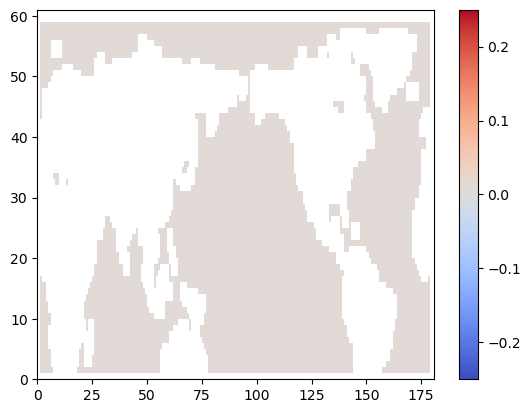

In [162]:
plt.pcolormesh(delta_p_2d_temp*100,vmin=-0.25,vmax=0.25,cmap='coolwarm')
plt.colorbar()

In [16]:
np.exp(shap_values.base_values[0])

array([1.6625098, 1.6544219, 1.6352499, 1.6058271, 1.6773043],
      dtype=float32)

In [146]:
time_i = 400
yval_time_i = y_predicted[time_i]

shap_values_temp_all_classes = shap_values[time_i].values
base_values_temp_all_classes = shap_values[time_i].base_values


# Compute P_0(base) again for reference
exp_base_values = np.exp(base_values_temp_all_classes)
P0_base = exp_base_values[0] / np.sum(exp_base_values)

# Now compute deltap contributed by each feature
exps = np.exp(base_values_temp_all_classes + shap_values_temp_all_classes) #each row is a feature
exps_class = exps[:,yval_time_i] 
p0_withf = exps_class/np.sum(exps,axis=1)
delta_p = p0_withf-P0_base

In [106]:
exp_with_f

array([1.6625098, 1.6544219, 1.6352499, 1.6058271, 1.6773043],
      dtype=float32)

In [ ]:
delta_P = np.exp(base_values_temp_all_classes + shap_values_temp_all_classes)[:,yval_time_i]

In [133]:
exps_class

array([1.6625098, 1.6625098, 1.6625098, ..., 1.6625098, 1.6625098,
       1.6625098], dtype=float32)

0.004764527

In [148]:
P0_base + np.sum(delta_p)

0.20664024

In [120]:
exps


array([[1.6625098, 1.6544219, 1.6352499, 1.6058271, 1.6773043],
       [1.6625098, 1.6544219, 1.6352499, 1.6058271, 1.6773043],
       [1.6625098, 1.6544219, 1.6352499, 1.6058271, 1.6773043],
       ...,
       [1.6625098, 1.6544219, 1.6352499, 1.6058271, 1.6772156],
       [1.6625098, 1.6544219, 1.6348785, 1.6058271, 1.6783112],
       [1.6625098, 1.6544219, 1.6352499, 1.6050861, 1.6469421]],
      dtype=float32)

In [118]:
p0

array([0.00018419, 0.0001842 , 0.0001842 , 0.0001842 , 0.0001842 ],
      dtype=float32)

In [116]:
exps_class

array([0.00018419, 0.0001842 , 0.0001842 , 0.0001842 , 0.0001842 ],
      dtype=float32)

array([9025.8955, 8981.617 , 8877.565 , 8718.073 , 9106.076 ],
      dtype=float32)

In [99]:
np.sum(delta_P)+P0_base

0.20664024353027344

In [ ]:
prob_denominator = np.sum(np.exp(shap_values.values[time_i].sum(axis=0) + shap_values.base_values[time_i]))


In [47]:
np.exp(shap_values.values[time_i].sum(axis=0) + shap_values.base_values[time_i]) \
    / prob_denominator

array([0.20667411, 0.19986339, 0.19649582, 0.19238786, 0.20457885],
      dtype=float32)

In [45]:
y_predicted_probs.iloc[time_i]

0    0.206674
1    0.199863
2    0.196496
3    0.192388
4    0.204579
Name: 1984-11-05 00:00:00, dtype: float32

In [59]:
np.exp(shap_values.base_values[time_i])/prob_denominator

array([0.20321639, 0.20222777, 0.19988428, 0.1962878 , 0.2050248 ],
      dtype=float32)

In [61]:
( np.exp(shap_values.values[time_i][:,yval_time_i]))/ prob_denominator

array([0.1222347, 0.1222347, 0.1222347, ..., 0.1222347, 0.1222347,
       0.1222347], dtype=float32)

In [79]:
np.exp(np.sum(shap_values.values[time_i][:,yval_time_i])) * np.exp(shap_values.base_values[time_i][yval_time_i])/prob_denominator

0.20667411

In [73]:
np.sum(( np.exp(shap_values.values[time_i][:,yval_time_i])-1 ) /prob_denominator) + np.exp(shap_values.base_values[time_i][yval_time_i])/prob_denominator

0.2052902

In [57]:
prob_denominator

8.180983

In [74]:
np.exp(shap_values.base_values[time_i][yval_time_i])

1.6625098

In [93]:
base_values_temp_all_classes

array([0.5083284 , 0.50345165, 0.49179563, 0.473639  , 0.51718783],
      dtype=float32)